In [ ]:
from google.colab import files
uploaded=files.upload()

Saving tickets_english.csv to tickets_english.csv


In [ ]:
import pandas as pd
df=pd.read_csv('tickets_english.csv')
df.head()

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
1,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
2,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN
3,Concerns About Securing Medical Data on 2-in-1...,Inquiring about best practices for securing me...,Thank you for your concern regarding securing ...,Request,Technical Support,medium,en,Security,Product,Feature,IT,Tech Support,NaN,NaN,NaN
4,Problem with Integration,"The integration stopped working unexpectedly, ...",I will look into the problem and call you at <...,Problem,IT Support,high,en,Technical,Integration,Bug,Resolution,Outage,Documentation,NaN,NaN


In [ ]:
print(df.shape)
print(df['queue'].value_counts())
print(df[['subject','body']].isnull().sum())

(11923, 15)
queue
Technical Support                  3412
Product Support                    2232
Customer Service                   1859
IT Support                         1391
Billing and Payments               1302
Returns and Exchanges               582
Service Outages and Maintenance     442
Sales and Pre-Sales                 330
Human Resources                     205
General Inquiry                     168
Name: count, dtype: int64
subject    1032
body          1
dtype: int64


In [ ]:
df=df.copy()
df['subject']= df['subject'].fillna('')
df=df.dropna(subset=['body'])
df['text']=df['subject']+' '+df['body']

print(df.shape)
print(df['text'].isnull().sum())

(11922, 16)
0


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(
    df['text'], df['queue'],
    test_size=0.2,
    random_state=42,
    stratify=df['queue']
)

print(x_train.shape, x_test.shape)

(9537,) (2385,)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

vectorizer=TfidfVectorizer(max_features=5000,stop_words='english')
x_train_tfidf=vectorizer.fit_transform(x_train)
x_test_tfidf=vectorizer.transform(x_test)

model=LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(x_train_tfidf,y_train)

print("Antrenare completa")

Antrenare completa


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred=model.predict(x_test_tfidf)

print(classification_report(y_test,y_pred))

                                 precision    recall  f1-score   support

           Billing and Payments       0.70      0.69      0.70       261
               Customer Service       0.31      0.25      0.28       372
                General Inquiry       0.10      0.35      0.16        34
                Human Resources       0.25      0.61      0.35        41
                     IT Support       0.32      0.36      0.34       278
                Product Support       0.42      0.25      0.31       446
          Returns and Exchanges       0.22      0.41      0.28       116
            Sales and Pre-Sales       0.12      0.36      0.18        66
Service Outages and Maintenance       0.35      0.64      0.45        88
              Technical Support       0.54      0.35      0.43       683

                       accuracy                           0.37      2385
                      macro avg       0.33      0.43      0.35      2385
                   weighted avg       0.43      0

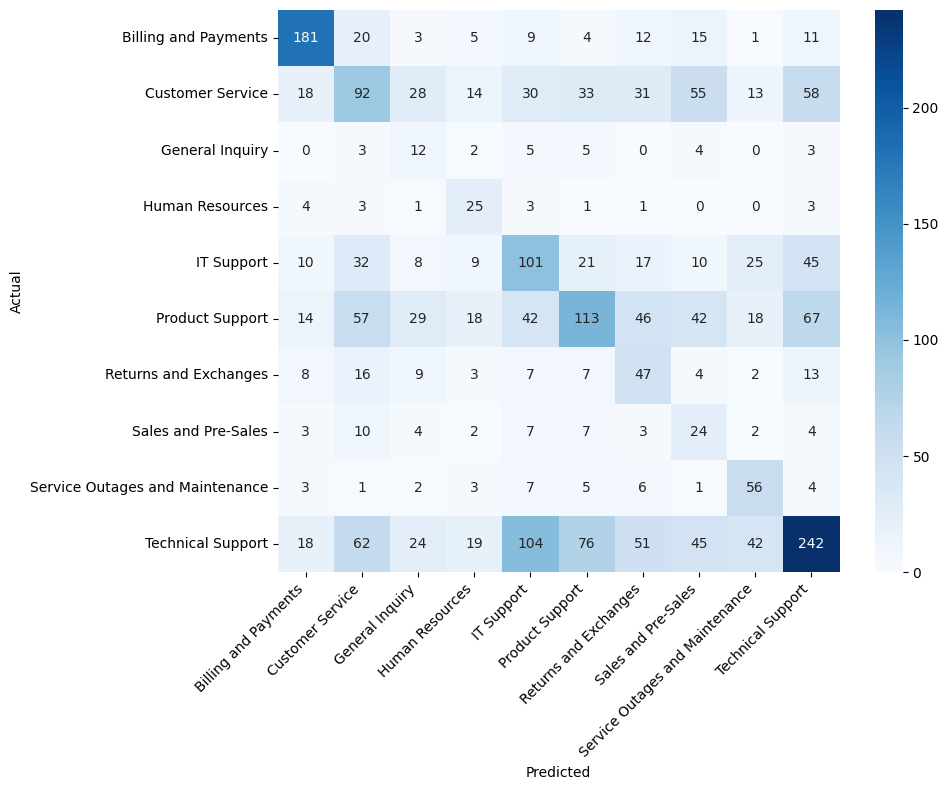

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(10,8))
cm=confusion_matrix(y_test,y_pred,labels=model.classes_)
sns.heatmap(cm,annot=True,fmt='d',xticklabels=model.classes_,yticklabels=model.classes_,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

!pip install transformers datasets accelerate -q


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder=LabelEncoder()
df['label']=label_encoder.fit_transform(df['queue'])
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

{'Billing and Payments': 0, 'Customer Service': 1, 'General Inquiry': 2, 'Human Resources': 3, 'IT Support': 4, 'Product Support': 5, 'Returns and Exchanges': 6, 'Sales and Pre-Sales': 7, 'Service Outages and Maintenance': 8, 'Technical Support': 9}


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels= train_test_split(
    df['text'].tolist(), df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)
print(len(train_texts), len(test_texts))

9537 2385


In [ ]:
from transformers import DistilBertTokenizer
tokenizer=DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_encodings=tokenizer(train_texts,truncation=True,padding=True, max_length=256)
test_encodings=tokenizer(test_texts,truncation=True,padding=True,max_length=256)

print("Tokenizare completa")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizare completa


In [ ]:
import torch

class TicketDataset(torch.utils.data.Dataset):
  def __init__(self,encodings,labels):
    self.encodings=encodings
    self.labels=labels

  def __getitem__(self,idx):
    item={key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    item['labels']=torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)

train_dataset=TicketDataset(train_encodings,train_labels)
test_dataset=TicketDataset(test_encodings,test_labels)

print(len(train_dataset), len(test_dataset))

9537 2385


In [ ]:
from transformers import DistilBertForSequenceClassification, TrainingArguments, Trainer
num_labels= len(label_encoder.classes_)

model_bert=DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)

training_args=TrainingArguments(
    output_dir='/results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
)

trainer=Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,1.721738,1.606346
2,1.529140,1.559827
3,1.364252,1.538217


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1791, training_loss=1.493337268073222, metrics={'train_runtime': 761.8165, 'train_samples_per_second': 37.556, 'train_steps_per_second': 2.351, 'total_flos': 1895282730316800.0, 'train_loss': 1.493337268073222, 'epoch': 3.0})

In [ ]:
predictions= trainer.predict(test_dataset)
y_pred_bert=predictions.predictions.argmax(axis=1)

from sklearn.metrics import classification_report

print(classification_report(test_labels,y_pred_bert,target_names=label_encoder.classes_))

                                 precision    recall  f1-score   support

           Billing and Payments       0.75      0.72      0.73       261
               Customer Service       0.32      0.37      0.34       372
                General Inquiry       0.00      0.00      0.00        34
                Human Resources       0.71      0.24      0.36        41
                     IT Support       0.34      0.18      0.23       278
                Product Support       0.39      0.38      0.38       446
          Returns and Exchanges       0.50      0.17      0.26       116
            Sales and Pre-Sales       0.75      0.05      0.09        66
Service Outages and Maintenance       0.75      0.43      0.55        88
              Technical Support       0.47      0.69      0.56       683

                       accuracy                           0.45      2385
                      macro avg       0.50      0.32      0.35      2385
                   weighted avg       0.46      0

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

class_weights= compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights=torch.tensor(class_weights,dtype=torch.float).to(model_bert.device)

class WeightedTrainer(Trainer):
  def compute_loss(self,model,inputs,return_outputs=False,**kwargs):
    labels=inputs.pop("labels")
    outputs=model(**inputs)
    logits=outputs.logits
    loss_fct=nn.CrossEntropyLoss(weight=class_weights)
    loss=loss_fct(logits.view(-1,model.config.num_labels), labels.view(-1))
    return (loss,outputs) if return_outputs else loss

trainer=WeightedTrainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,1.450598,1.887300
2,1.016945,1.944462
3,0.705760,1.991382


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1791, training_loss=0.9878876141367645, metrics={'train_runtime': 762.525, 'train_samples_per_second': 37.521, 'train_steps_per_second': 2.349, 'total_flos': 1895282730316800.0, 'train_loss': 0.9878876141367645, 'epoch': 3.0})

In [ ]:
predictions= trainer.predict(test_dataset)

y_pred_bert_weighted=predictions.predictions.argmax(axis=1)

print(classification_report(test_labels,y_pred_bert_weighted,target_names=label_encoder.classes_))

                                 precision    recall  f1-score   support

           Billing and Payments       0.59      0.78      0.67       261
               Customer Service       0.36      0.35      0.36       372
                General Inquiry       0.19      0.18      0.18        34
                Human Resources       0.45      0.32      0.37        41
                     IT Support       0.30      0.32      0.31       278
                Product Support       0.38      0.43      0.40       446
          Returns and Exchanges       0.23      0.20      0.21       116
            Sales and Pre-Sales       0.26      0.18      0.21        66
Service Outages and Maintenance       0.55      0.55      0.55        88
              Technical Support       0.49      0.42      0.45       683

                       accuracy                           0.42      2385
                      macro avg       0.38      0.37      0.37      2385
                   weighted avg       0.42      0

In [ ]:
trainer.save_model('./ticket-classifier-distilbert')
tokenizer.save_pretrained('./ticket-classifier-distilbert')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./ticket-classifier-distilbert/tokenizer_config.json',
 './ticket-classifier-distilbert/tokenizer.json')

In [ ]:
trainer.save_model('/content/drive/MyDrive/ticket-classifier-distilbert')
tokenizer.save_pretrained('/content/drive/MyDrive/ticket-classifier-distilbert')
print("Model salvat pe Drive!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model salvat pe Drive!


In [ ]:
!pip install sentence-transformers faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 93.1 MB/s eta 0:00:00


In [ ]:
from sentence_transformers import SentenceTransformer

embedder= SentenceTransformer('all-MiniLM-L6-v2')
print("Model de embeddings incarcat")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model de embeddings incarcat


In [ ]:
df_resolved = df.dropna(subset=['answer']).reset_index(drop=True)

ticket_embeddings=embedder.encode(df_resolved['text'].tolist(), show_progress_bar=True)

print(ticket_embeddings.shape)

Batches:   0%|          | 0/373 [00:00<?, ?it/s]

(11919, 384)


In [ ]:
!pip install sentence-transformers faiss-cpu -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss
import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
from sklearn.preprocessing import LabelEncoder

df_resolved= pd.read_csv('/content/drive/MyDrive/df_resolved.csv')
ticket_embeddings= np.load('/content/drive/MyDrive/ticket_embeddings.npy')

embeddings_np= ticket_embeddings.astype('float32')
dimension=embeddings_np.shape[1]
index=faiss.IndexFlatL2(dimension)
index.add(embeddings_np)

embedder=SentenceTransformer('all-MiniLM-L6-v2')

tokenizer=DistilBertTokenizer.from_pretrained('/content/drive/MyDrive/ticket-classifier-distilbert')
model_bert=DistilBertForSequenceClassification.from_pretrained('/content/drive/MyDrive/ticket-classifier-distilbert')
model_bert.to('cuda' if torch.cuda.is_available() else 'cpu')

label_encoder=LabelEncoder()
label_encoder.fit(df_resolved['queue'])

print("Totul incarcat din Drive, gata de lucru!")

Mounted at /content/drive


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

Totul incarcat din Drive, gata de lucru!


In [ ]:
query="My card was charged twice for the same order"

query_embedding= embedder.encode([query]).astype('float32')

k=5
distances, indices=index.search(query_embedding,k)

for i, idx in enumerate(indices[0]):
  print(f"--- Rezultat {i+1} (distanta: {distances[0][i]:.2f}) ---")
  print("Subject:", df_resolved.iloc[idx]['subject'])
  print("Queue:", df_resolved.iloc[idx]['queue'])
  print("Answer:", df_resolved.iloc[idx]['answer'][:150], "...")
  print()

--- Rezultat 1 (distanta: 0.77) ---
Subject: Double Charges on Recent Subscriptions - Issue Exist
Queue: Billing and Payments
Answer: Dear [Name], we apologize for the billing issues you are experiencing with double charges on recent subscriptions. We would like to assist in resolvin ...

--- Rezultat 2 (distanta: 0.77) ---
Subject: Resolving Unintended Duplicate Billing Problem
Queue: Billing and Payments
Answer: Hello <name>, we acknowledge your email concerning the unintended duplicate billing issue. We regret the inconvenience caused and are willing to help  ...

--- Rezultat 3 (distanta: 0.77) ---
Subject: Problem with Monthly Subscription Being Charged Twice
Queue: Billing and Payments
Answer: <name>, I'm sorry to hear that you were charged twice for the monthly subscription. We will investigate the matter and work on refunding the extra cha ...

--- Rezultat 4 (distanta: 0.80) ---
Subject: Problem with Monthly Subscription Double Charging
Queue: Billing and Payments
Answer: <nam

In [ ]:
def find_similar_tickets(query_text, k=5):
  query_embedding=embedder.encode([query_text]).astype('float32')
  distaces, indices=index.search(query_embedding, k)
  results= []
  for i,idx in enumerate(indices[0]):
    results.append({
        'subject': df_resolved.iloc[idx]['subject'],
        'queue': df_resolved.iloc[idx]['queue'],
        'answer': df_resolved.iloc[idx]['answer'],
        'distance': distances[0][i]
    })
  return results

In [ ]:
def predict_category(text):
  inputs=tokenizer(text,truncation=True, padding=True, max_length=256, return_tensors='pt')
  inputs= {k: v.to(model_bert.device) for k, v in inputs.items()}

  with torch.no_grad():
    outputs= model_bert(**inputs)

  predicted_label=outputs.logits.argmax(dim=1).item()
  predicted_category= label_encoder.inverse_transform([predicted_label])[0]
  return predicted_category

In [ ]:
def find_similar_tickets_filtered(query_text,k=5):
  predicted_category= predict_category(query_text)

  mask=df_resolved['queue']== predicted_category
  filtered_df= df_resolved[mask].reset_index(drop=True)
  filtered_embeddings=ticket_embeddings[mask.values].astype('float32')

  temp_index=faiss.IndexFlatL2(filtered_embeddings.shape[1])
  temp_index.add(filtered_embeddings)

  query_embedding=embedder.encode([query_text]).astype('float32')
  distances, indices=temp_index.search(query_embedding,min(k,len(filtered_df)))

  results= []
  for i, idx in enumerate(indices[0]):
    results.append({
        'subject': filtered_df.iloc[idx]['subject'],
        'queue': filtered_df.iloc[idx]['queue'],
        'answer': filtered_df.iloc[idx]['answer'],
        'distance': distances[0][i]
    })
  return predicted_category, results

In [ ]:
category, results= find_similar_tickets_filtered("My card was charged twice for the same order")
print("Categorie prezisa:", category)
print()
for i, r in enumerate(results):
  print(f"--- Rezultat {i+1} (distanta: {r['distance']:.2f}) ---")
  print("Subject:", r['subject'])
  print("Queue:", r['queue'])
  print("Answer:", r['answer'][:150], "...")
  print()

Categorie prezisa: Billing and Payments

--- Rezultat 1 (distanta: 0.77) ---
Subject: Double Charges on Recent Subscriptions - Issue Exist
Queue: Billing and Payments
Answer: Dear [Name], we apologize for the billing issues you are experiencing with double charges on recent subscriptions. We would like to assist in resolvin ...

--- Rezultat 2 (distanta: 0.77) ---
Subject: Resolving Unintended Duplicate Billing Problem
Queue: Billing and Payments
Answer: Hello <name>, we acknowledge your email concerning the unintended duplicate billing issue. We regret the inconvenience caused and are willing to help  ...

--- Rezultat 3 (distanta: 0.77) ---
Subject: Problem with Monthly Subscription Being Charged Twice
Queue: Billing and Payments
Answer: <name>, I'm sorry to hear that you were charged twice for the monthly subscription. We will investigate the matter and work on refunding the extra cha ...

--- Rezultat 4 (distanta: 0.80) ---
Subject: Problem with Monthly Subscription Double Charging

In [ ]:
import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
from sklearn.preprocessing import LabelEncoder

tokenizer= DistilBertTokenizer.from_pretrained('/content/drive/MyDrive/ticket-classifier-distilbert')
model_bert=DistilBertForSequenceClassification.from_pretrained('/content/drive/MyDrive/ticket-classifier-distilbert')
model_bert.to('cuda' if torch.cuda.is_available() else 'cpu')

label_encoder = LabelEncoder()
label_encoder.fit(df_resolved['queue'])

print("Model DistilBERT incarcat din Drive")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model DistilBERT incarcat din Drive


In [ ]:
query_test= "I have a problem with my account"

query_embedding= embedder.encode([query_test]).astype('float32')
distances_all, indices_all= index.search(query_embedding, 5)

print("=== FARA filtrare (toate categoriile) ===")
for i, idx in enumerate(indices_all[0]):
  print(f"{i+1}. Queue: {df_resolved.iloc[idx]['queue']} (distanta: {distances_all[0][i]:.2f})")

print()

category, results= find_similar_tickets_filtered(query_test)
print(f"=== CU filtrare (categorie prezisa: {category}) ===")
for i, r in enumerate(results):
  print(f"{i+1}. Queue: {r['queue']} (distanta: {r['distance']:.2f})")

=== FARA filtrare (toate categoriile) ===
1. Queue: Billing and Payments (distanta: 0.69)
2. Queue: Customer Service (distanta: 0.70)
3. Queue: Customer Service (distanta: 0.78)
4. Queue: Billing and Payments (distanta: 0.80)
5. Queue: Billing and Payments (distanta: 0.83)

=== CU filtrare (categorie prezisa: Customer Service) ===
1. Queue: Customer Service (distanta: 0.70)
2. Queue: Customer Service (distanta: 0.78)
3. Queue: Customer Service (distanta: 0.94)
4. Queue: Customer Service (distanta: 0.94)
5. Queue: Customer Service (distanta: 0.94)


In [ ]:
import torch.nn.functional as F

def predict_category_with_confidence(text):
  inputs= tokenizer(text,truncation=True, padding=True, max_length=256, return_tensors='pt')
  inputs={k: v.to(model_bert.device) for k, v in inputs.items()}

  with torch.no_grad():
    outputs= model_bert(**inputs)

  probs= F.softmax(outputs.logits,dim=1)
  confidence, predicted_label=torch.max(probs,dim=1)

  predicted_category= label_encoder.inverse_transform([predicted_label.item()])[0]
  return predicted_category, confidence.item()

In [ ]:
def find_similar_tickets_hybrid(query_text, k=5, confidence_threshold=0.5):
  predicted_category, confidence= predict_category_with_confidence(query_text)
  query_embedding=embedder.encode([query_text]).astype('float32')

  if confidence >= confidence_threshold:
    mask=df_resolved['queue']== predicted_category
    filtered_df=df_resolved[mask].reset_index(drop=True)
    filtered_embeddings=ticket_embeddings[mask.values].astype('float32')

    temp_index= faiss.IndexFlatL2(filtered_embeddings.shape[1])
    temp_index.add(filtered_embeddings)

    distances, indices= temp_index.search(query_embedding, min(k, len(filtered_df)))
    source_df=filtered_df
    mode="filtrat"
  else:
    distances, indices=index.search(query_embedding,k)
    source_df=df_resolved
    mode="nefiltrat"

  results= []
  for i, idx in enumerate(indices[0]):
    results.append({
        'subject': source_df.iloc[idx]['subject'],
        'queue': source_df.iloc[idx]['queue'],
        'answer': source_df.iloc[idx]['answer'],
        'distance': distances[0][i]
    })
  return predicted_category, confidence, mode, results

In [ ]:
for query in ["My card was charged twice for the same order", "I have a problem with my account"]:
  category, confidence, mode, results= find_similar_tickets_hybrid(query,confidence_threshold=0.6)
  print(f"Query: {query}")
  print(f"Categorie prezisa: {category} | Incredere: {confidence:.2f} | Mod: {mode}")
  for i, r in enumerate(results):
    print(f" {i+1}. Queue: {r['queue']} (distanta: {r['distance']:.2f})")
  print()

Query: My card was charged twice for the same order
Categorie prezisa: Billing and Payments | Incredere: 1.00 | Mod: filtrat
 1. Queue: Billing and Payments (distanta: 0.77)
 2. Queue: Billing and Payments (distanta: 0.77)
 3. Queue: Billing and Payments (distanta: 0.77)
 4. Queue: Billing and Payments (distanta: 0.80)
 5. Queue: Billing and Payments (distanta: 0.80)

Query: I have a problem with my account
Categorie prezisa: Customer Service | Incredere: 0.41 | Mod: nefiltrat
 1. Queue: Billing and Payments (distanta: 0.69)
 2. Queue: Customer Service (distanta: 0.70)
 3. Queue: Customer Service (distanta: 0.78)
 4. Queue: Billing and Payments (distanta: 0.80)
 5. Queue: Billing and Payments (distanta: 0.83)



In [ ]:
!pip install google-genai -q

In [ ]:
from google.colab import userdata
from google import genai

client_gemini= genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

print("Client Gemini configurat")

Client Gemini configurat


In [ ]:
def generate_response(ticket_text, similar_results):
  context=""
  for i, r in enumerate(similar_results):
    context+=f"\nExemplu {i+1}: \nTicket similar: {r['subject']}\nSolutie folosita: {r['answer']}\n"
  prompt= f"""Esti un asistent de suport clienti. Ai primit un ticket nou de la un client:

"{ticket_text}"

Iata cateva cazuri similare rezolvate anterior, care te pot ajuta sa formulezi un raspuns:
{context}

Scrie un raspuns profesional si empatic pentru ticketul nou, inspirat din exemplele de mai sus, dar adaptat specific la acest caz."""
  response=client_gemini.models.generate_content(
      model='gemini-3.5-flash-lite',
      contents=prompt
  )
  return response.text

In [ ]:
ticket_nou= "My card was charged twice for the same order"

category, confidence, mode, results = find_similar_tickets_hybrid(ticket_nou)
raspuns_generat=generate_response(ticket_nou,results)

print("Categorie:", category)
print("Incredere:", confidence)
print("\nRaspuns generat:\n")
print(raspuns_generat)

Categorie: Billing and Payments
Incredere: 0.9960402250289917

Raspuns generat:

Iată o propunere de răspuns profesional și empatic, inspirată din cazurile anterioare și adaptată pentru situația clientului:

***

**Subject:** Re: My card was charged twice for the same order

Dear [Name],

I am very sorry to hear that your card was charged twice for the same order. We completely understand how frustrating this situation can be, and we are here to help resolve this matter as quickly as possible.

We will investigate this issue right away and work on processing a refund for the extra charge. To help us locate the transaction and speed up the investigation, could you please provide us with your **account number** and the **exact date** of the duplicate charge? 

Please allow us 24–48 hours to look into the system and identify the source of the error. We will keep you updated on our progress regarding the refund and any additional steps needed. 

If you prefer to discuss this over the phone

In [ ]:
import time
def generate_response_with_retry(ticket_text, similar_results, max_retries=6):
  for attempt in range(max_retries):
    try:
      return generate_response(ticket_text,similar_results)
    except Exception as e:
      print(f"Incercare {attempt+1}/{max_retries} esuata: {e}")
      if attempt< max_retries -1:
        wait_time= 15* (attempt+1)
        print(f"Astept {wait_time} secunde...")
        time.sleep(wait_time)
    return None

In [ ]:
def process_ticket(ticket_text):
  category, confidence, mode, results=find_similar_tickets_hybrid(ticket_text)
  response= generate_response_with_retry(ticket_text,results)
  return {
      'category': category,
      'confidence': confidence,
      'mode': mode,
      'generated_response': response
  }

In [ ]:
test_tickets= [
    "My card was charged twice for the same order",
    "The product I received is defective and I want a refund",
    "I'm having trouble logging into my account",
    "I have a problem with my account"
]

for ticket in test_tickets:
  print("=" * 60)
  print(f"TICKET: {ticket}")
  print("="*60)
  result=process_ticket(ticket)
  print(f"Categorie: {result['category']} | Incredere: {result['confidence']:.2f} | Mod: {result['mode']}")
  print(f"\nRaspuns generat:\n{result['generated_response']}")
  print()

TICKET: My card was charged twice for the same order
Categorie: Billing and Payments | Incredere: 1.00 | Mod: filtrat

Raspuns generat:
Iată o propunere de răspuns profesională și empatică, inspirată din cazurile anterioare:

***

**Subject:** Re: My card was charged twice for the same order

Dear [Name],

I am very sorry to hear that your card was charged twice for the same order. We completely understand how frustrating this situation can be, and we want to assure you that we are here to help resolve this matter as quickly as possible.

To assist us with our investigation and to ensure we issue a refund for the extra charge promptly, could you please provide us with your account number [Account Number] and the date of the transaction? 

Please allow us 24-48 hours to look into the billing system and identify the source of the error. We will keep you updated regarding the refund and any additional steps needed. 

If you prefer to discuss this further over the phone, please let us know

In [ ]:
def route_ticket(ticket_text, confidence_threshold=0.5, distance_threshold=0.85):
  category, confidence, mode, results= find_similar_tickets_hybrid(ticket_text)
  min_distance= min(r['distance'] for r in results) if results else float('inf')

  if confidence >= confidence_threshold and min_distance <= distance_threshold:
    decision = "AUTO_RESOLVE"
    response = generate_response_with_retry(ticket_text, results)
  else:
    decision = "ESCALATE_TO_HUMAN"
    response= None

  return {
      'ticket': ticket_text,
      'category': category,
      'confidence': confidence,
      'retrieval_mode': mode,
      'min_distance': min_distance,
      'decision': decision,
      'generated_response': response
  }

In [ ]:
test_tickets= [
    "My card was charged twice for the same order",
    "The product I received is defective and I want a refund",
    "I'm having trouble logging into my account",
    "I have a problem with my account",
    "asdf random text nothing specific help"
]

for ticket in test_tickets:
  result= route_ticket(ticket,confidence_threshold=0.6)
  print("="*60)
  print(f"TICKET: {result['ticket']}")
  print(f"{ticket[:50]:50} | Incredere: {result['confidence']:.2f} | Distanta min: {result['min_distance']:.2f}")
  print(f"DECIZIE: {result['decision']}")
  if result['decision'] == "AUTO_RESOLVE":
    print(f"\nRaspuns generat:\n{result['generated_response']}")
  else:
    print("\n-> Trimis catre un agent uman pentru evaluare manuala.")
  print()

TICKET: My card was charged twice for the same order
My card was charged twice for the same order       | Incredere: 1.00 | Distanta min: 0.77
DECIZIE: AUTO_RESOLVE

Raspuns generat:
Salut! Iată un răspuns profesional și empatic, inspirat din cazurile anterioare, pe care îl poți trimite clientului (în limba engleză, menținând limba în care a fost scris ticketul):

***

**Subject:** Re: My card was charged twice for the same order

Dear [Name],

I am very sorry to hear that your card was charged twice for the same order. We completely understand how frustrating this situation can be, and we apologize for the inconvenience caused. 

We will investigate this matter immediately and work on issuing a refund for the extra charge as soon as possible. To assist us with a fast resolution, could you please provide your account number and the exact date of the transaction? 

Please allow 24-48 hours for our team to look into the issue. We will keep you updated regarding the refund status and any 